# plotting 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

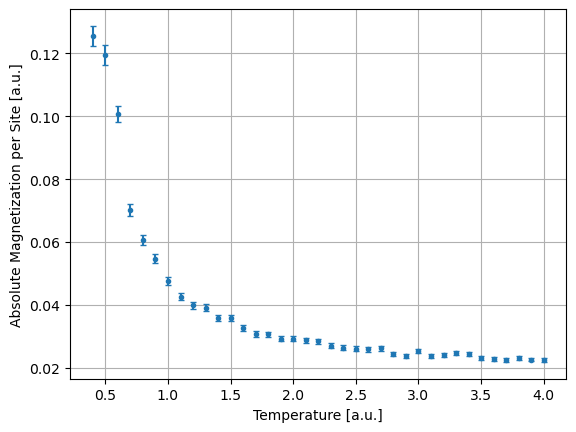

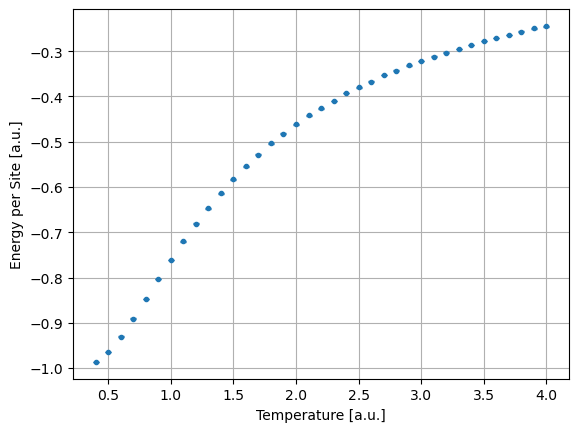

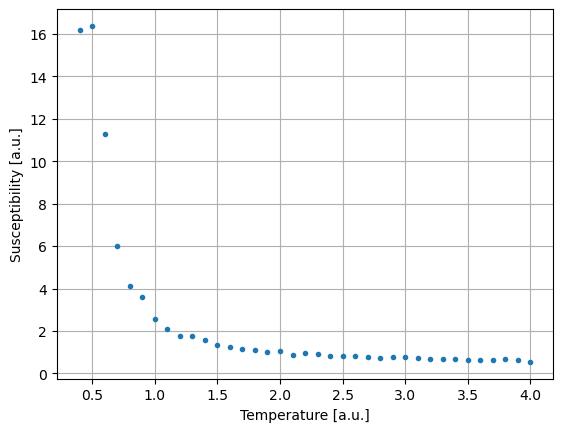

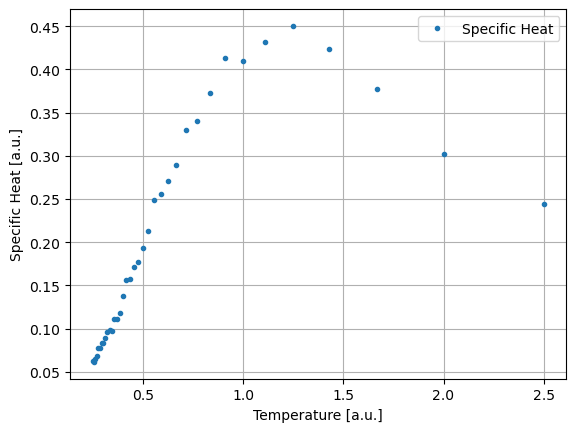

In [ ]:
# plotting FFT
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

measurements = np.genfromtxt('measurements.csv', delimiter=',')
N_measurements = measurements[:,0]
magnetization = measurements[:,1]
var_magnetization = measurements[:,2]
var2_magnetization = measurements[:,3]
energy = measurements[:,4]
var_energy = measurements[:,5]
var2_energy = measurements[:,6]

parameters = np.genfromtxt('parameters.csv', delimiter=',')
N_sites = parameters[:,0]
temperature = parameters[:,1]
N_steps = parameters[:,3]
N_skip = parameters[:,4]

susceptibility = var_magnetization*N_sites
specificHeat = var_energy/N_sites

# remember to correct for the number of measurements
# remember to correct with Bessel correction for the variance
error_magnetization = np.sqrt(var_magnetization) / np.sqrt(N_measurements - 1)
error_energy = np.sqrt(var_energy) / np.sqrt(N_measurements - 1)

energy_per_site = energy / N_sites
error_energy_per_site = error_energy / N_sites

error_susceptibility = np.sqrt(var2_magnetization)*np.sqrt(N_sites)
error_specificHeat = np.sqrt(var2_energy)/(N_measurements - 1)

def theoretical_specific_heat(T):
    K=1/T
    return (-K**2*np.sinh(K)**158+K**2*np.cosh(K)**)

x_temperature = np.linspace(temperature.min(), temperature.max(), 100)

plt.errorbar(temperature, magnetization, yerr=error_magnetization, fmt='.', linestyle='', capsize=2, label='Magnetization')
plt.xlabel('Temperature [a.u.]')
plt.ylabel('Absolute Magnetization per Site [a.u.]')
plt.grid()
plt.show()

plt.errorbar(temperature, energy_per_site, yerr=error_energy_per_site, fmt='.', linestyle='', capsize=2, label='Energy')
plt.xlabel('Temperature [a.u.]')
plt.ylabel('Energy per Site [a.u.]')
plt.grid()
plt.show()

plt.errorbar(temperature, susceptibility, yerr=error_susceptibility, fmt='.', linestyle='', capsize=2, label='Susceptibility')
plt.xlabel('Temperature [a.u.]')
plt.ylabel('Susceptibility [a.u.]')
plt.grid()
plt.show()

plt.errorbar(1/temperature, 1/temperature**2*specificHeat, fmt='.', linestyle='', capsize=2, label='Specific Heat')
# plt.plot(1/x_temperature, theoretical_specific_heat(x_temperature), label='Theoretical Specific Heat')
plt.xlabel('Temperature [a.u.]')
plt.ylabel('Specific Heat [a.u.]')
plt.grid()
plt.legend()
plt.show()